# K-Means Clustering – ausführlich erläutert

**Datensatz:** Juwelier-Beispiel – Körpergröße vs. Ringfingerumfang  
**Lernziele:**
- Den K-Means-Algorithmus Schritt für Schritt nachvollziehen
- Die Ellbogen-Methode zur Bestimmung des optimalen k anwenden
- Den Einfluss von Feature Scaling auf das Clustering-Ergebnis verstehen
- K-Means in scikit-learn trainieren und visualisieren

---
**Kontext aus der Vorlesung:** Wir sind Juwelier und wollen 2, 3 oder maximal 4 Standardring-Größen anbieten.  
Dazu clustern wir unsere Kundendaten nach Körpergröße und Ringfingerumfang.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── Datensatz ──────────────────────────────────────────────────────────────
data = {
    'Körpergröße (cm)':    [153.3, 158.9, 160.8, 179.6, 156.6,
                             165.1, 165.9, 156.7, 167.8, 160.8],
    'Ringfingerumfang (mm)': [47.1, 46.8, 49.3, 53.2, 47.7,
                               49.0, 50.6, 47.1, 51.7, 47.8]
}
df = pd.DataFrame(data)
X  = df[['Körpergröße (cm)', 'Ringfingerumfang (mm)']].values

print("Datensatz (10 Kund:innen):")
print(df.to_string(index=True))

Datensatz (10 Kund:innen):
   Körpergröße (cm)  Ringfingerumfang (mm)
0             153.3                   47.1
1             158.9                   46.8
2             160.8                   49.3
3             179.6                   53.2
4             156.6                   47.7
5             165.1                   49.0
6             165.9                   50.6
7             156.7                   47.1
8             167.8                   51.7
9             160.8                   47.8


## 1 · Direktes K-Means mit scikit-learn (k = 2, 3, 4)

scikit-learn erledigt den gesamten Algorithmus in einer Zeile.  
Wir probieren verschiedene k-Werte und schauen uns das Ergebnis visuell an.

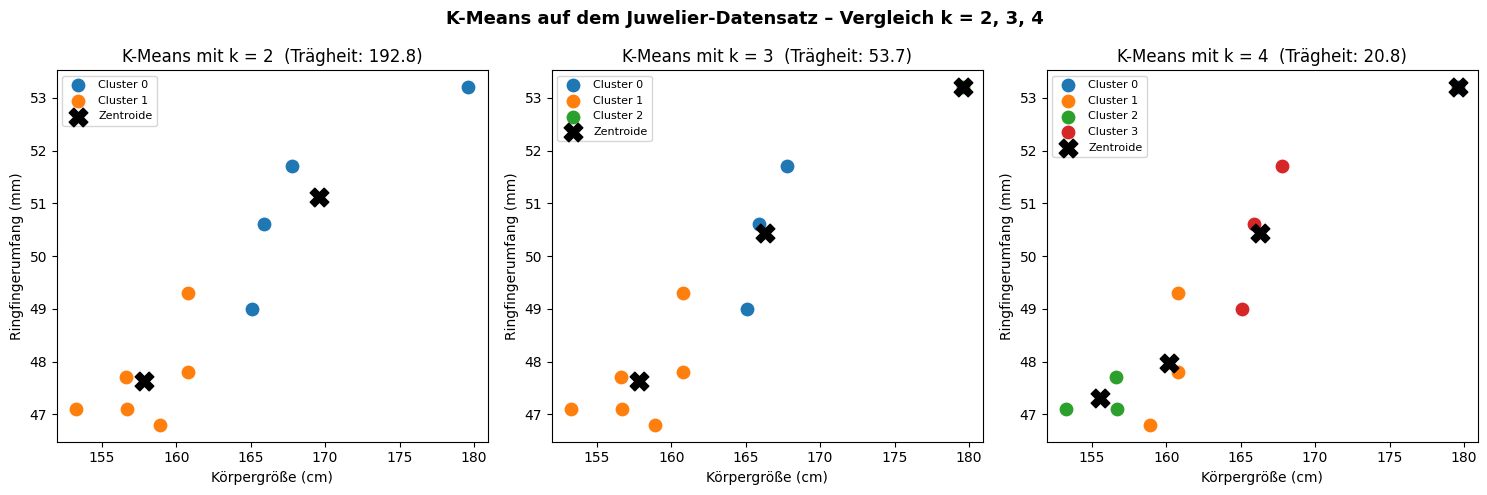

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']

for ax, k in zip(axes, [2, 3, 4]):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=colors[cluster_id], s=80, label=f'Cluster {cluster_id}')
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=180, zorder=5, label='Zentroide')
    ax.set_xlabel('Körpergröße (cm)')
    ax.set_ylabel('Ringfingerumfang (mm)')
    ax.set_title(f'K-Means mit k = {k}  (Trägheit: {km.inertia_:.1f})')
    ax.legend(fontsize=8)

plt.suptitle('K-Means auf dem Juwelier-Datensatz – Vergleich k = 2, 3, 4',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2 · Schrittweise Visualisierung des Algorithmus (k = 3)

Wir implementieren K-Means von Grund auf und visualisieren jede Iteration.  
So wird die Konvergenz des Algorithmus sichtbar.

**Schritte je Iteration:**
1. Alle Punkte dem nächsten Zentroid zuweisen (Zuweisung)
2. Zentroide als Mittelwert der zugewiesenen Punkte neu berechnen (Update)

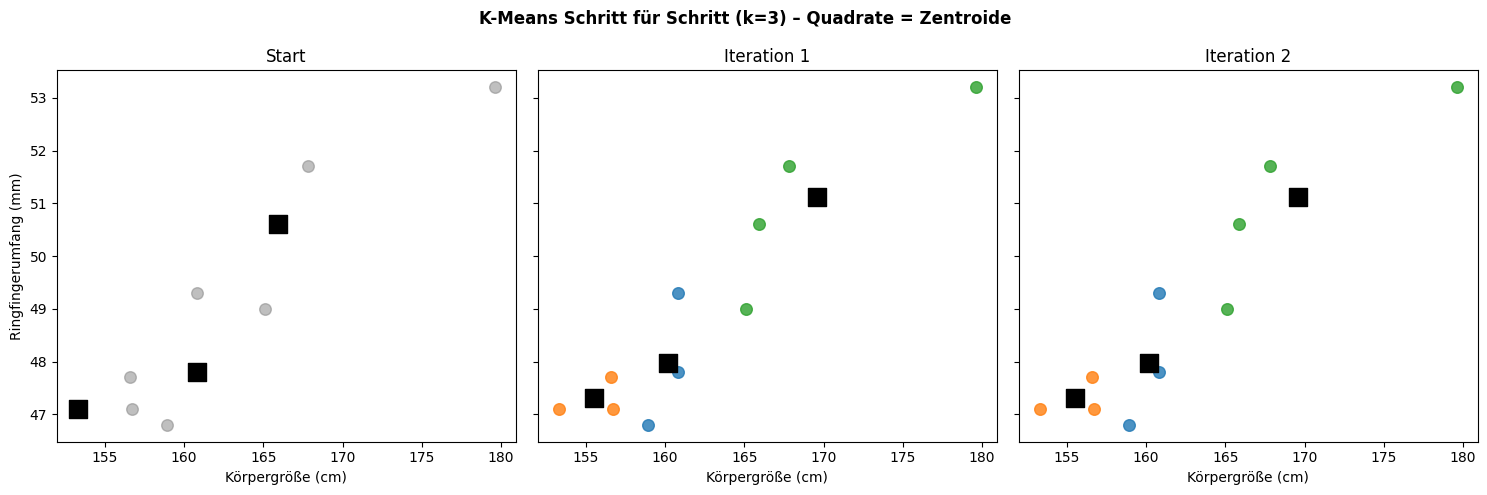

Konvergiert nach 2 Iteration(en)


In [3]:
from sklearn.metrics import pairwise_distances_argmin

def kmeans_step_by_step(X, n_clusters, max_iters=10, seed=42):
    # K-Means von Grund auf - gibt Verlauf jeder Iteration zurueck
    rng = np.random.default_rng(seed)
    # Zufällige Initialisierung (Standard, kein K-Means++)
    idx = rng.choice(len(X), n_clusters, replace=False)
    centers = X[idx].copy()
    history = [(centers.copy(), None)]  # (Zentroide, Labels)

    for _ in range(max_iters):
        labels = pairwise_distances_argmin(X, centers)
        new_centers = np.array([X[labels == i].mean(axis=0)
                                 for i in range(n_clusters)])
        history.append((new_centers.copy(), labels.copy()))
        if np.allclose(centers, new_centers):
            break
        centers = new_centers

    return history

n_clusters = 3
history = kmeans_step_by_step(X, n_clusters)
colors = ['#1F77B4', '#FF7F0E', '#2CA02C']

n_steps = len(history)
fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 5, 5), sharey=True)
if n_steps == 1:
    axes = [axes]

for step, (centers, labels) in enumerate(history):
    ax = axes[step]
    if labels is not None:
        for i in range(n_clusters):
            mask = labels == i
            ax.scatter(X[mask, 0], X[mask, 1],
                       c=colors[i], s=70, alpha=0.8)
    else:
        ax.scatter(X[:, 0], X[:, 1], c='grey', s=70, alpha=0.5)
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='s', s=160, zorder=5)
    ax.set_xlabel('Körpergröße (cm)')
    ax.set_title('Start' if step == 0 else f'Iteration {step}')
    if step == 0:
        ax.set_ylabel('Ringfingerumfang (mm)')

plt.suptitle(f'K-Means Schritt für Schritt (k={n_clusters}) – Quadrate = Zentroide',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Konvergiert nach {len(history) - 1} Iteration(en)")

## 3 · Ellbogen-Methode: das optimale k finden

Die **Trägheit (Inertia)** sinkt immer wenn k steigt – bei k = n wäre sie 0.  
Der **Ellbogenpunkt** ist der k-Wert, ab dem die Trägheit nur noch wenig sinkt.

> **Beobachtungsauftrag:** Wo liegt der Ellbogen bei diesem Datensatz?

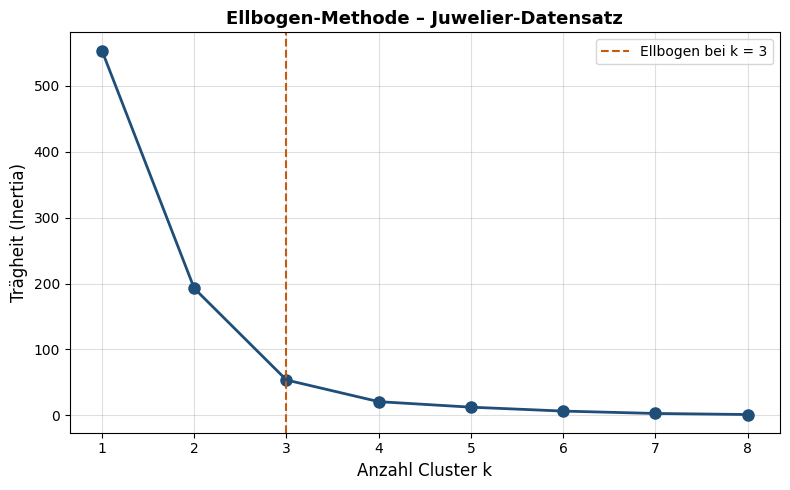

Trägheit je k:
  k=1: 553.39
  k=2: 192.78
  k=3: 53.70
  k=4: 20.83
  k=5: 12.46
  k=6: 6.53
  k=7: 2.91
  k=8: 1.31


In [4]:
inertias = []
k_range = range(1, 9)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, 'o-', color='#1F4E79', linewidth=2, markersize=8)
ax.set_xlabel('Anzahl Cluster k', fontsize=12)
ax.set_ylabel('Trägheit (Inertia)', fontsize=12)
ax.set_title('Ellbogen-Methode – Juwelier-Datensatz', fontsize=13, fontweight='bold')
ax.set_xticks(list(k_range))
ax.grid(True, alpha=0.4)

# Ellbogen-Markierung
best_k = 3  # visuell / fachlich begründet
ax.axvline(x=best_k, color='#C55A11', linestyle='--', linewidth=1.5,
           label=f'Ellbogen bei k = {best_k}')
ax.legend()
plt.tight_layout()
plt.show()

print("Trägheit je k:")
for k, inertia in zip(k_range, inertias):
    print(f"  k={k}: {inertia:.2f}")

## 4 · Feature Scaling – warum Normalisierung wichtig ist

K-Means basiert auf **euklidischen Distanzen**.  
Merkmale mit größerem Wertebereich dominieren die Distanzberechnung:

- Körpergröße: 153–180 cm → Bereich ~ 27 cm  
- Ringfingerumfang: 47–53 mm → Bereich ~ 6 mm

Die Körpergröße hat ca. **4,5× mehr absoluten Einfluss** als der Ringfingerumfang!

> **Lösung:** Z-Transformation → Mittelwert 0, Standardabweichung 1

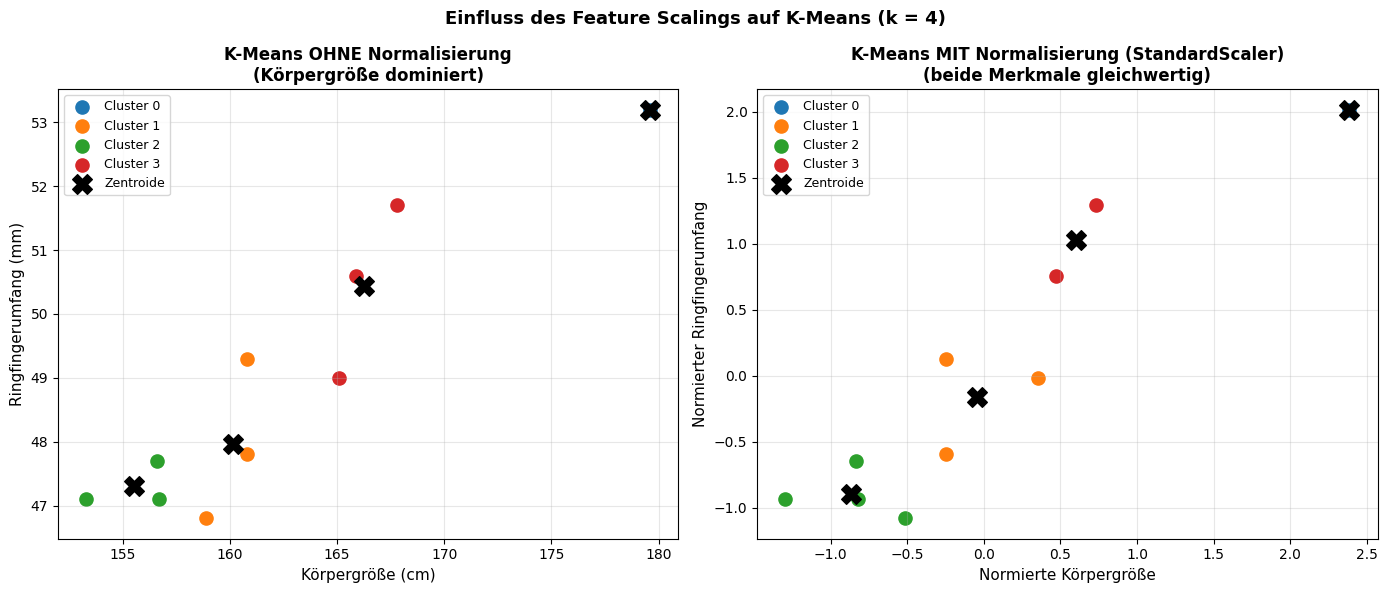

Ohne Normalisierung:
  Cluster sind vertikal orientiert → Körpergröße dominiert

Mit Normalisierung (StandardScaler):
  Cluster spiegeln die tatsächliche Datenstruktur wider


In [5]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (X_in, title, xlabel, ylabel) in zip(axes, [
    (X,        '''K-Means OHNE Normalisierung
(Körpergröße dominiert)''',
     'Körpergröße (cm)', 'Ringfingerumfang (mm)'),
    (X_scaled, '''K-Means MIT Normalisierung (StandardScaler)
(beide Merkmale gleichwertig)''',
     'Normierte Körpergröße', 'Normierter Ringfingerumfang'),
]):
    km = KMeans(n_clusters=4, n_init=10, random_state=42)
    labels = km.fit_predict(X_in)
    centers = km.cluster_centers_
    colors_c = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']
    for i in range(4):
        mask = labels == i
        ax.scatter(X_in[mask, 0], X_in[mask, 1],
                   c=colors_c[i], s=90, label=f'Cluster {i}')
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=200, zorder=5, label='Zentroide')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Einfluss des Feature Scalings auf K-Means (k = 4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Ohne Normalisierung:")
print("  Cluster sind vertikal orientiert → Körpergröße dominiert")
print()
print("Mit Normalisierung (StandardScaler):")
print("  Cluster spiegeln die tatsächliche Datenstruktur wider")

## 5 · K-Means++ vs. zufällige Initialisierung

Schlechte Startpunkte können zu suboptimalen Clustern führen.  
**K-Means++** wählt Startpunkte mit maximalem gegenseitigem Abstand – bessere Ergebnisse!

> In scikit-learn ist `init='k-means++'` bereits die **Standardeinstellung**.

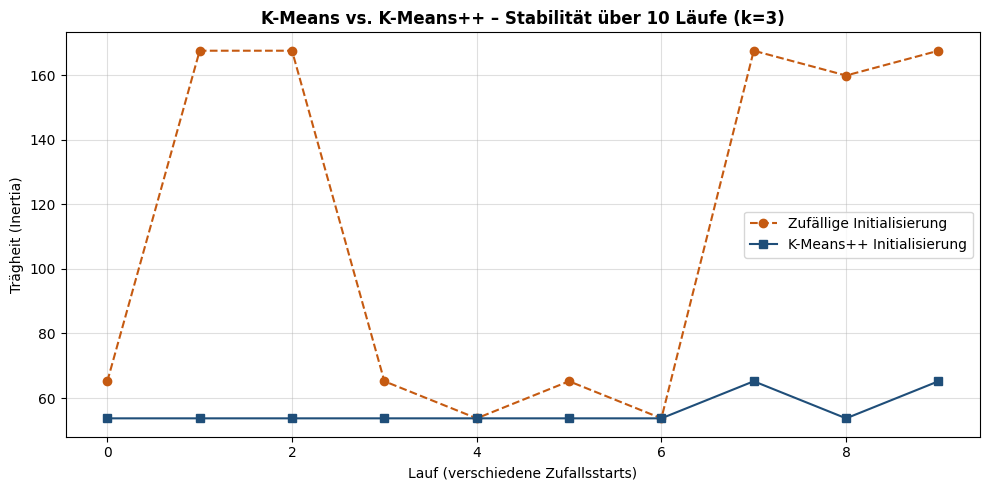

Zufällige Initialisierung: Ø Trägheit = 113.32  (Varianz = 2800.99)
K-Means++ Initialisierung: Ø Trägheit = 56.00  (Varianz = 21.12)


In [6]:
n_runs = 10
k = 3

inertias_random = []
inertias_kpp = []

for seed in range(n_runs):
    km_r = KMeans(n_clusters=k, init='random', n_init=1, random_state=seed)
    km_r.fit(X)
    inertias_random.append(km_r.inertia_)

    km_p = KMeans(n_clusters=k, init='k-means++', n_init=1, random_state=seed)
    km_p.fit(X)
    inertias_kpp.append(km_p.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(n_runs)
ax.plot(x, inertias_random, 'o--', color='#C55A11', label='Zufällige Initialisierung')
ax.plot(x, inertias_kpp,    's-',  color='#1F4E79', label='K-Means++ Initialisierung')
ax.set_xlabel('Lauf (verschiedene Zufallsstarts)')
ax.set_ylabel('Trägheit (Inertia)')
ax.set_title(f'K-Means vs. K-Means++ – Stabilität über {n_runs} Läufe (k={k})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Zufällige Initialisierung: Ø Trägheit = {sum(inertias_random)/n_runs:.2f}  "
      f"(Varianz = {float(np.var(inertias_random)):.2f})")
print(f"K-Means++ Initialisierung: Ø Trägheit = {sum(inertias_kpp)/n_runs:.2f}  "
      f"(Varianz = {float(np.var(inertias_kpp)):.2f})")

## Zusammenfassung

| Konzept | Erkenntnis |
|---------|-----------|
| **K-Means** | Partitioniert Daten in k Cluster durch iterativen Zuweisungs- und Update-Schritt |
| **Trägheit** | Interne Qualitätsmetrik – sinkt immer mit steigendem k |
| **Ellbogen-Methode** | Findet den Trade-off zwischen Trägheit und Clusteranzahl |
| **Feature Scaling** | Zwingend nötig bei unterschiedlich skalierten Merkmalen |
| **K-Means++** | Bessere Initialisierung → stabilere, qualitativ hochwertigere Ergebnisse |

> **Lernfragen:**
> 1. Warum konvergiert K-Means immer – aber nicht zwingend zum globalen Optimum?
> 2. An welchem Punkt liegt der Ellbogen im Juwelier-Datensatz?
> 3. Was würde passieren, wenn wir k = 10 wählen?

Frage 1 – Konvergenz vs. globales Optimum: Konvergenz ist beweisbar, weil die Trägheit monoton sinkt und nach unten beschränkt ist. Das globale Optimum wird nicht garantiert, weil das Ergebnis von der Startinitialisierung abhängt – deshalb n_init=10.

Frage 2 – Ellbogen: k = 3 ist die Antwort, mit inhaltlicher Begründung (S/M/L) und Hinweis darauf, dass der Ellbogen nicht immer eindeutig ist.

Frage 3 – k = 10: Jeder Punkt wird sein eigenes Cluster – Trägheit nahezu 0, aber bedeutungslos. Die Analogie zum Overfitting macht das Konzept greifbar.

Bonusfrage – K-Means++: Erklärt das Auswahlprinzip (Wahrscheinlichkeit proportional zum quadrierten Abstand) in einfacher Sprache.